## 지도학습
### 회귀 분석 ▪ Linear Regression 

### 분류 분석 ▪ Logistic Regression ▪ K-Nearest Neighbor ▪ Decision Tree ▪ Random Forest ▪ XGBoosting ▪ SVM(Support Vector Machine) 

## 비지도학습
### 군집분석(Clustering) ▪ K-means Clustering ▪ Hierarchical Clustering ▪ Density Clustering

### 입력변수 1개인 선형회기(Linear Regression) 모델

In [1]:
import numpy as np

x_data = np.array([1,2,3,4,5]).reshape(5,1) # 독립변수
t_data = np.array([2,3,4,5,6]).reshape(5,1) # 종속변수

W = np.random.rand(1,1)
b = np.random.rand(1)

In [2]:
def loss_func(x, t): # 손실함수(비용함수)
    y = np.dot(x,W) + b
    return (np.sum((t - y)**2 )) / (len(x)) #MSE 평균제곱오차

In [3]:
def numerical_derivative(f, x):   # 수치 미분 함수
    delta_x = 1e-4
    grad = np.zeros_like(x)
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        idx = it.multi_index
        tmp_val = x[idx]

        x[idx] = float(tmp_val) + delta_x
        fx1 = f(x)   # f(x+delta_x)
        x[idx] = float(tmp_val) - delta_x
        fx2 = f(x)   # f(x-delta_x)
        grad[idx] = (fx1 - fx2) / (2*delta_x)

        x[idx] = tmp_val
        it.iternext()
    return grad

In [4]:
learning_rate = 1e-2   # 학습율a
f = lambda x : loss_func(x_data, t_data)
print("Initial loss value = ", loss_func(x_data, t_data), "Initial W = ", W, "\n", ", b = ", b )

for step in range(6001):
    W -= learning_rate * numerical_derivative(f, W)
    b -= learning_rate * numerical_derivative(f, b)
    if (step % 300 == 0):
        print("step = ", step, "loss value = ", loss_func(x_data, t_data), "W =", W, "b =", b)

Initial loss value =  14.533037666155384 Initial W =  [[0.01596235]] 
 , b =  [0.40297539]
step =  0 loss value =  8.558540015512886 W = [[0.26827211]] b = [0.45881955]
step =  300 loss value =  0.00301847487626644 W = [[1.03567718]] b = [0.87122559]
step =  600 loss value =  0.0003832068429684409 W = [[1.01271198]] b = [0.95411693]
step =  900 loss value =  4.864956327862506e-05 W = [[1.00452935]] b = [0.9836516]
step =  1200 loss value =  6.176246720616706e-06 W = [[1.00161383]] b = [0.99417497]
step =  1500 loss value =  7.840979647735765e-07 W = [[1.00057502]] b = [0.99792451]
step =  1800 loss value =  9.9544212880904e-08 W = [[1.00020488]] b = [0.99926049]
step =  2100 loss value =  1.2637515671877765e-08 W = [[1.000073]] b = [0.99973651]
step =  2400 loss value =  1.6043805836326864e-09 W = [[1.00002601]] b = [0.99990612]
step =  2700 loss value =  2.036822049531254e-10 W = [[1.00000927]] b = [0.99996655]
step =  3000 loss value =  2.5858229048190354e-11 W = [[1.0000033]] b = [0

In [5]:
def predict(x):
    y = np.dot(x,W) + b
    return y

In [6]:
predict(np.array([43]))

array([44.])

## 다중회귀

In [7]:
import numpy as np

loaded_data = np.loadtxt('./data_01.csv', delimiter=',', dtype=np.float32)
x_data = loaded_data[:, 0:-1]
t_data = loaded_data[:, [-1]]

print('x_data.ndim = ', x_data.ndim, ", x_data.shape = ", x_data.shape)
print('t_data.ndim = ', t_data.ndim, ", t_data.shape = ", t_data.shape)

x_data.ndim =  2 , x_data.shape =  (9, 3)
t_data.ndim =  2 , t_data.shape =  (9, 1)


In [8]:
x_data

array([[ 73.,  80.,  75.],
       [ 93.,  88.,  93.],
       [ 89.,  91.,  90.],
       [ 96.,  98., 100.],
       [ 73.,  66.,  70.],
       [ 53.,  46.,  55.],
       [ 69.,  74.,  77.],
       [ 47.,  56.,  60.],
       [ 87.,  79.,  90.]], dtype=float32)

In [9]:
t_data

array([[152.],
       [185.],
       [180.],
       [196.],
       [142.],
       [101.],
       [149.],
       [115.],
       [175.]], dtype=float32)

In [10]:
np.random.seed(42)
W = np.random.rand(3,1)
b = np.random.rand(1)
print("W = ", W, ", W.shape = ", W.shape, ", b = ", b, ", b.shape = ", b.shape)

W =  [[0.37454012]
 [0.95071431]
 [0.73199394]] , W.shape =  (3, 1) , b =  [0.59865848] , b.shape =  (1,)


In [11]:
learning_rate = 1e-5   
f = lambda x : loss_func(x_data, t_data)
print("Initial loss value = ", loss_func(x_data, t_data) )

for step in range(30001):
    W -= learning_rate * numerical_derivative(f, W)
    b -= learning_rate * numerical_derivative(f, b)
    if (step % 300 == 0):
        print("step = ", step, "loss value = ", loss_func(x_data, t_data), "W =", W, "b =", b)

Initial loss value =  18.912018958218844
step =  0 loss value =  11.964774630423404 W = [[0.36933621]
 [0.94535252]
 [0.72658915]] b = [0.59861768]
step =  300 loss value =  6.718608878884632 W = [[0.37657351]
 [0.90182075]
 [0.73444869]] b = [0.59898902]
step =  600 loss value =  6.238106572073905 W = [[0.39056818]
 [0.87061379]
 [0.75089825]] b = [0.59940598]
step =  900 loss value =  5.8422692897017585 W = [[0.40250021]
 [0.84233207]
 [0.7665289 ]] b = [0.59979593]
step =  1200 loss value =  5.514951867483427 W = [[0.4126218 ]
 [0.81667871]
 [0.78138247]] b = [0.60015952]
step =  1500 loss value =  5.24322543168234 W = [[0.42115622]
 [0.79338826]
 [0.79549856]] b = [0.60049745]
step =  1800 loss value =  5.0167224354469955 W = [[0.42830099]
 [0.77222328]
 [0.80891464]] b = [0.60081047]
step =  2100 loss value =  4.827116484137607 W = [[0.43423081]
 [0.75297136]
 [0.82166619]] b = [0.60109931]
step =  2400 loss value =  4.667709073556348 W = [[0.43910013]
 [0.73544239]
 [0.8337868 ]]

In [12]:
test_data = np.array([[100,98,81]])
predict(test_data)

array([[179.13680055]])

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression().fit(x_data, t_data)
print(model.coef_, model.intercept_)      # 가중치, 절편

[[0.38179067 0.5078318  1.127576  ]] [-1.0562897]


In [14]:
test_data = np.array([[100,98,81]])
pred_data = model.predict(test_data)
pred_data

array([[178.22395015]])

In [15]:
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv("boston_house.csv")
df.head(2)

,AGE,B,RM,CRIM,DIS,INDUS,LSTAT,NOX,PTRATIO,RAD,ZN,TAX,CHAS,Target
0,65.2,396.9,6.575,0.00632,4.0900,2.31,4.98,0.538,15.3,1,18.0,296,0,24.0
1,78.9,396.9,6.421,0.02731,4.9671,7.07,9.14,0.469,17.8,2,0.0,242,0,21.6


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   AGE      506 non-null    float64
 1   B        506 non-null    float64
 2   RM       506 non-null    float64
 3   CRIM     506 non-null    float64
 4   DIS      506 non-null    float64
 5   INDUS    506 non-null    float64
 6   LSTAT    506 non-null    float64
 7   NOX      506 non-null    float64
 8   PTRATIO  506 non-null    float64
 9   RAD      506 non-null    int64  
 10  ZN       506 non-null    float64
 11  TAX      506 non-null    int64  
 12  CHAS     506 non-null    int64  
 13  Target   506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [17]:
dfx = df.drop(['Target'], axis = 1)
dfx.head(2)

,AGE,B,RM,CRIM,DIS,INDUS,LSTAT,NOX,PTRATIO,RAD,ZN,TAX,CHAS
0,65.2,396.9,6.575,0.00632,4.0900,2.31,4.98,0.538,15.3,1,18.0,296,0
1,78.9,396.9,6.421,0.02731,4.9671,7.07,9.14,0.469,17.8,2,0.0,242,0


In [18]:
dfy = df['Target']
dfy

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: Target, Length: 506, dtype: float64

In [19]:
X_train, X_test, y_train, y_test = train_test_split(dfx, dfy, random_state=42)

In [20]:
X_train.shape, X_test.shape

((379, 13), (127, 13))

In [21]:
X_train.head(5)

,AGE,B,RM,CRIM,DIS,INDUS,LSTAT,NOX,PTRATIO,RAD,ZN,TAX,CHAS
182,92.2,394.12,7.155,0.09103,2.7006,2.46,4.82,0.4880,17.8,3,0.0,193,0
155,82.6,88.01,6.152,3.53501,1.7455,19.58,15.02,0.8710,14.7,5,0.0,403,1
280,64.5,387.31,7.820,0.03578,4.6947,3.33,3.76,0.4429,14.9,5,20.0,216,0
126,95.6,359.29,5.613,0.38735,1.7572,25.65,27.26,0.5810,19.1,2,0.0,188,0
329,17.2,375.21,6.333,0.06724,5.2146,3.24,7.34,0.4600,16.9,4,0.0,430,0


In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
score = model.score(X_test, y_test) # 정확도(결정계수를 사용)
print('정확도 : ',score)
cofficient = model.coef_
intercept = model.intercept_
print("계수 : ", cofficient)
print("절편 : ", intercept)

정확도 :  0.6844267283527149
계수 :  [-9.24808158e-03  1.31854199e-02  4.36875476e+00 -1.28322638e-01
 -1.40086668e+00  4.88590934e-02 -5.17639519e-01 -1.62388292e+01
 -9.23122944e-01  2.57761243e-01  2.95517751e-02 -9.95694820e-03
  2.77350326e+00]
절편 :  29.836420163839076


In [24]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
model_boston = LinearRegression().fit(X_train_scaled, y_train)
print(model_boston.coef_)
print(model_boston.intercept_)

[ -0.89798872   5.22907382  21.48116718 -11.41649808 -15.40519074
   1.29623175 -18.75925615  -7.89207097  -8.67735568   5.92850858
   2.95517751  -5.21744086   2.77350326]
24.78285485913331


In [26]:
model_boston.score(X_train_scaled, y_train)

0.748087259862344

In [27]:
model_boston.score(X_test_scaled, y_test)

0.6844267283527131

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
model_boston = LinearRegression().fit(X_train_scaled, y_train)
print(model_boston.coef_)
print(model_boston.intercept_)

[-0.25586276  1.15235744  3.14172655 -1.06546379 -2.95561026  0.33928836
 -3.69504236 -1.93178062 -2.08714915  2.21416067  0.68154987 -1.65127265
  0.73726309]
22.90791556728232


In [30]:
model_boston.score(X_train_scaled, y_train)

0.748087259862344

In [31]:
model_boston.score(X_test_scaled, y_test)

0.6844267283527121

In [32]:
from sklearn.metrics import mean_squared_error

mean_squared_error(y_train, model_boston.predict(X_train_scaled)) # MSE

22.340057992152875

In [33]:
import math

math.sqrt(mean_squared_error(y_train, model_boston.predict(X_train_scaled))) # RMSE

4.7265270539956585

In [38]:
from sklearn.metrics import r2_score

y_pred = model_boston.predict(X_test_scaled)
r2_score(y_test, y_pred) # 결정계수

0.6844267283527121

## 다중 회귀식의 추정방법
▪ 동시 입력법
• 모든 독립변수들을 포함하여 분석하는 방법
• 이를 통해 특정 독립변수의 영향력을 알 수 있음

▪ 단계적 선택법
• 다른 변수들이 회귀식에 존재할 때 종속변수에 영향력이 있는 변수들만을 회귀식에 포함시키는 방법
• 설명력이 높은 즉, 유의 확률 p가 가장 작은 변수의 순으로 회귀식에 포함시킴

▪ 후진 소거법
• 모든 독립변수를 모두 포함시킨 상태에서 기여도가 적은 변수부터 하나씩 제거해서 모델에 남아있는
변수들의 유의확률이 유의수준 이하가 될 때까지 삭제하는 방법

▪ 전진 선택법
• 독립변수가 하나도 포함되지 않은 모델에서 시작해서 F 값에 가장 큰 기여를 하는 변수(유의확률 p가
가장 작은)를 순서대로 하나씩 더해가는 방법


In [39]:
import statsmodels.api as sm

Boston = sm.datasets.get_rdataset("Boston", package="MASS")
boston_df = Boston.data
boston_df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [43]:
import statsmodels.formula.api as smf

formula = "medv~" + "+".join(boston_df.iloc[:,:-1].columns)
formula # 포뮬러 실

'medv~crim+zn+indus+chas+nox+rm+age+dis+rad+tax+ptratio+black+lstat'

In [47]:
# OLS: 최소자승법(OLS)을 활용한 단순 선형 회귀 모델
#     실제 데이터의 y값(실제값)과 추세선의 y값(예측값)의 차를 잔차(Residual)라고 한다.
#     최종자승법은 이 잔차의 제곱의 합을 최소로 하는 방법이다.
mdoel_boston = smf.ols(formula=formula, data = boston_df).fit()
mdoel_boston.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     108.1
Date:                Tue, 28 Apr 2026   Prob (F-statistic):          6.72e-135
Time:                        14:20:25   Log-Likelihood:                -1498.8
No. Observations:                 506   AIC:                             3026.
Df Residuals:                     492   BIC:                             3085.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     36.4595      5.103      7.144      0.000      26.432      46.487
crim          -0.1080      0.033     -3.287      0.001      -0.173      -0.043
zn             0.0464      0.014      3.382      0.001       0.019       0.073
indus          0.0206      0.061      0.334      0.738      -0.100       0.141
chas           2.6867      0.862      3.118      0.002       0.994       4.380
nox          -17.7666      3.820     -4.651      0.000     -25.272     -10.262
rm             3.8099      0.418      9.116      0.000       2.989       4.631
age            0.0007      0.013      0.052      0.958      -0.025       0.027
dis           -1.4756      0.199     -7.398      0.000      -1.867      -1.084
rad            0.3060      0.066      4.613      0.000       0.176       0.436
tax           -0.0123      0.004     -3.280      0.001      -0.020      -0.005
ptratio       -0.9527      0.131     -7.283      0.000      -1.210      -0.696
black          0.0093      0.003      3.467      0.001       0.004       0.015
lstat         -0.5248      0.051    -10.347      0.000      -0.624      -0.425
==============================================================================
Omnibus:                      178.041   Durbin-Watson:                   1.078
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              783.126
Skew:                           1.521   Prob(JB):                    8.84e-171
Kurtosis:                       8.281   Cond. No.                     1.51e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.51e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [49]:
formula = "medv~rad+zn+rm+chas+age-1"
model_boston2 = smf.ols(formula=formula, data = boston_df).fit()
model_boston2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                   medv   R-squared (uncentered):                   0.932
Model:                            OLS   Adj. R-squared (uncentered):              0.931
Method:                 Least Squares   F-statistic:                              1363.
Date:                Tue, 28 Apr 2026   Prob (F-statistic):                   5.05e-289
Time:                        14:22:17   Log-Likelihood:                         -1654.6
No. Observations:                 506   AIC:                                      3319.
Df Residuals:                     501   BIC:                                      3340.
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
rad           -0.2183      0.037     -5.924      0.000      -0.291      -0.146
zn             0.0161      0.015      1.056      0.291      -0.014       0.046
rm             4.7232      0.147     32.166      0.000       4.435       5.012
chas           5.6944      1.128      5.047      0.000       3.478       7.911
age           -0.0792      0.012     -6.358      0.000      -0.104      -0.055
==============================================================================
Omnibus:                      234.375   Durbin-Watson:                   0.708
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1253.471
Skew:                           2.008   Prob(JB):                    6.49e-273
Kurtosis:                       9.583   Cond. No.                         299.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 다중공선성 파악하는 방법
산점도 그래프

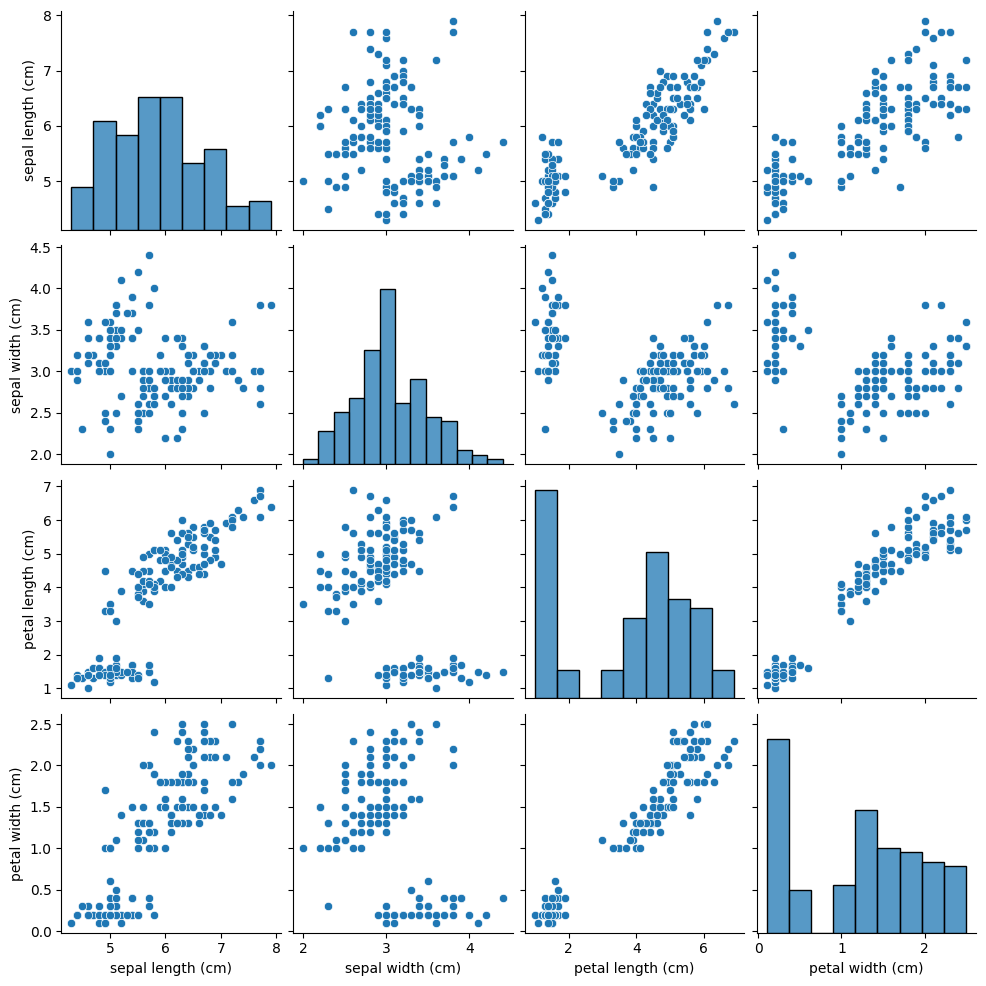

In [50]:
from sklearn.datasets import load_iris
import pandas as pd
import seaborn as sns

dataset = load_iris()
iris = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
sns.pairplot(iris)

In [51]:
iris.corr()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.117570,0.871754,0.817941
sepal width (cm),-0.117570,1.000000,-0.428440,-0.366126
petal length (cm),0.871754,-0.428440,1.000000,0.962865
petal width (cm),0.817941,-0.366126,0.962865,1.000000


In [52]:
import statsmodels.api as sm

Boston = sm.datasets.get_rdataset("Boston", package="MASS")
boston_df = Boston.data

formula = "medv~" + "+".join(boston_df.iloc[:,:-1].columns)
formula

'medv~crim+zn+indus+chas+nox+rm+age+dis+rad+tax+ptratio+black+lstat'

In [55]:
from patsy import dmatrices # 디자인 행렬 함수 : 종속변수와 독립변수를 분할 시켜줌

y, X = dmatrices(formula, boston_df, return_type="dataframe")

In [57]:
y

,medv
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2
...,...
501,22.4
502,20.6
503,23.9
504,22.0


In [58]:
X

,Intercept,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat
0,1.0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,1.0,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,1.0,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,1.0,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,1.0,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,1.0,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,1.0,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,1.0,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,1.0,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


In [62]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor # VIF 계산 함수

vif = pd.DataFrame()
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif["features"] = X.columns
vif

,VIF Factor,features
0,585.265238,Intercept
1,1.792192,crim
2,2.298758,zn
3,3.991596,indus
4,1.073995,chas
5,4.393720,nox
6,1.933744,rm
7,3.100826,age
8,3.955945,dis
9,7.484496,rad


In [68]:
from patsy import dmatrices 
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

def get_vif(formula, df):
    y, X = dmatrices(formula, boston_df, return_type="dataframe")
    vif = pd.DataFrame()
    vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif["features"] = X.columns
    return vif

In [71]:
formula = "medv~" + "+".join(boston_df.iloc[:,:-1].columns) + "-1"
print(formula)
get_vif(formula, boston_df)

medv~crim+zn+indus+chas+nox+rm+age+dis+rad+tax+ptratio+black+lstat-1


,VIF Factor,features
0,2.100373,crim
1,2.844013,zn
2,14.485758,indus
3,1.152952,chas
4,73.894947,nox
5,77.948283,rm
6,21.386850,age
7,14.699652,dis
8,15.167725,rad
9,61.227274,tax


In [72]:
formula = "medv~crim+zn+indus+chas+nox+rm+age+dis+rad+tax+black+lstat-1"
print(formula)
get_vif(formula, boston_df)

medv~crim+zn+indus+chas+nox+rm+age+dis+rad+tax+black+lstat-1


,VIF Factor,features
0,2.099345,crim
1,2.451624,zn
2,14.275283,indus
3,1.142167,chas
4,73.894171,nox
5,60.598846,rm
6,21.361234,age
7,12.221605,dis
8,15.159162,rad
9,59.301541,tax


In [73]:
formula = "medv~crim+zn+indus+chas+rm+age+dis+rad+tax+black+lstat-1"
print(formula)
get_vif(formula, boston_df)

medv~crim+zn+indus+chas+rm+age+dis+rad+tax+black+lstat-1


,VIF Factor,features
0,2.097537,crim
1,2.449661,zn
2,13.150904,indus
3,1.138277,chas
4,41.406746,rm
5,19.889623,age
6,12.032952,dis
7,15.155012,rad
8,57.720347,tax
9,18.396072,black


In [74]:
formula = "medv~crim+zn+indus+chas+rm+age+dis+rad+black+lstat-1"
print(formula)
get_vif(formula, boston_df)

medv~crim+zn+indus+chas+rm+age+dis+rad+black+lstat-1


,VIF Factor,features
0,2.097466,crim
1,2.375219,zn
2,9.290080,indus
3,1.118613,chas
4,39.069063,rm
5,19.780944,age
6,11.817803,dis
7,4.965633,rad
8,18.289917,black
9,9.046248,lstat


In [75]:
formula = "medv~crim+zn+indus+chas+age+dis+rad+black+lstat-1"
print(formula)
get_vif(formula, boston_df)

medv~crim+zn+indus+chas+age+dis+rad+black+lstat-1


,VIF Factor,features
0,2.095367,crim
1,2.334763,zn
2,9.016142,indus
3,1.116229,chas
4,14.000758,age
5,8.447694,dis
6,4.771767,rad
7,13.537020,black
8,8.358925,lstat


In [76]:
formula = "medv~crim+zn+indus+chas+dis+rad+black+lstat-1"
print(formula)
get_vif(formula, boston_df)

medv~crim+zn+indus+chas+dis+rad+black+lstat-1


,VIF Factor,features
0,2.095211,crim
1,2.313889,zn
2,8.205465,indus
3,1.106350,chas
4,8.209371,dis
5,4.689836,rad
6,10.074224,black
7,6.856889,lstat


In [78]:
formula = "medv~crim+zn+indus+chas+dis+rad+lstat-1"
print(formula)
get_vif(formula, boston_df)

medv~crim+zn+indus+chas+dis+rad+lstat-1


,VIF Factor,features
0,2.067135,crim
1,2.299351,zn
2,6.900077,indus
3,1.086574,chas
4,3.968908,dis
5,4.678181,rad
6,6.726973,lstat


In [79]:
import statsmodels.formula.api as smf

mdoel_boston = smf.ols(formula=formula, data = boston_df).fit()
mdoel_boston.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                   medv   R-squared (uncentered):                   0.822
Model:                            OLS   Adj. R-squared (uncentered):              0.820
Method:                 Least Squares   F-statistic:                              330.1
Date:                Tue, 28 Apr 2026   Prob (F-statistic):                   1.03e-182
Time:                        15:26:35   Log-Likelihood:                         -1895.9
No. Observations:                 506   AIC:                                      3806.
Df Residuals:                     499   BIC:                                      3835.
Df Model:                           7                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
crim          -0.1840      0.071     -2.599      0.010      -0.323      -0.045
zn             0.0529      0.027      1.970      0.049       0.000       0.106
indus          0.8391      0.092      9.098      0.000       0.658       1.020
chas           9.1546      1.820      5.031      0.000       5.580      12.730
dis            3.6821      0.211     17.469      0.000       3.268       4.096
rad            0.1755      0.077      2.283      0.023       0.024       0.327
lstat         -0.3776      0.082     -4.606      0.000      -0.539      -0.217
==============================================================================
Omnibus:                       94.793   Durbin-Watson:                   0.469
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              163.764
Skew:                           1.110   Prob(JB):                     2.75e-36
Kurtosis:                       4.686   Cond. No.                         107.
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## 정규화 선형회귀(Ridge, Lasso, Elastic-net)

In [80]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

data = load_diabetes()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, random_state=42)

In [81]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [83]:
y_train

array([166., 189., 173., 220., 206.,  97.,  60.,  61., 242., 121., 128.,
       104., 265., 132., 283., 174., 129., 257., 137.,  63.,  93., 232.,
       208., 261., 179., 258., 262.,  51., 237.,  71., 139., 268.,  69.,
       317., 249., 154., 192., 116.,  81., 122., 259., 191., 292.,  55.,
       107., 210.,  91., 253.,  85., 252.,  59.,  78., 200.,  78., 245.,
       175.,  42., 127.,  53.,  94., 104., 199., 265., 281., 248., 257.,
       215., 303., 170.,  59., 277., 209., 138., 198., 124.,  96., 288.,
       225., 265., 101.,  55., 198.,  51., 252.,  64., 220., 131., 212.,
       142., 103., 155., 121.,  86., 111.,  65., 131.,  51., 128., 141.,
        48., 109., 178.,  88.,  84., 216., 150.,  60.,  96., 190.,  74.,
       279., 182., 160., 245., 276., 174., 180., 150., 196., 138.,  97.,
       246., 321., 308., 109.,  69., 182., 258., 161., 178., 214.,  45.,
       150., 160.,  55., 197., 185., 268., 310., 123.,  68.,  72., 185.,
       144., 147., 168., 178., 246., 151., 127.,  8

In [84]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge.score(X_test, y_test)

0.43840029731424435

In [89]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)
lasso.score(X_test, y_test)

0.3791413953419158

In [98]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet(alpha=1.0, l1_ratio=0.5)
elastic.fit(X_train, y_train)
elastic.score(X_test, y_test)

-0.004438393929198314

In [99]:
from sklearn.linear_model import LinearRegression
import pandas as pd
import numpy as np

linear = LinearRegression()
linear.fit(X_train, y_train)

coefs = np.vstack((linear.coef_, ridge.coef_, lasso.coef_, elastic.coef_))
index = ['linear', 'ridge', 'lasso', 'elastic']
coefs_df = pd.DataFrame(coefs, columns=data.feature_names, index=index)
print("정규화 선형회귀 모델별 가중치(계수) 비교")
coefs_df

정규화 선형회귀 모델별 가중치(계수) 비교


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
linear,47.749681,-241.990907,531.971063,381.562862,-918.502905,508.257783,116.950164,269.492303,695.808117,26.324582
ridge,50.552012,-67.722224,278.301228,197.622638,-6.245836,-26.226726,-151.394331,120.323359,215.854463,101.755774
lasso,0.000000,-0.000000,398.385831,46.175421,0.000000,0.000000,-0.000000,0.000000,238.187309,0.000000
elastic,0.413088,0.000000,3.298991,2.256916,0.339380,0.080784,-1.874661,2.143869,2.947963,1.701981
